In [1]:
import warnings
warnings.filterwarnings('ignore')

from typing import Annotated
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class state(TypedDict):
    message: Annotated[list, add_messages]

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()
key = os.getenv('GROQ_API_KEY')
from langchain_groq import ChatGroq
chat_model = ChatGroq(model='openai/gpt-oss-120b', api_key=key)
chat_model

def chatbot(state:state):
    return{'message': [chat_model.invoke(state['message'])]}

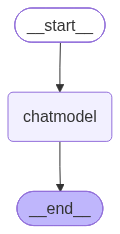

In [7]:
building = StateGraph(state)

building.add_node('chatmodel',chatbot)

building.add_edge(START,'chatmodel')
building.add_edge('chatmodel',END)
graph = building.compile()
graph


In [11]:
from langchain_core.messages import HumanMessage
response = graph.invoke({
    'message':[
        HumanMessage(content='what is langGraph')
    ]
})
response['message'][-1].content

'**LangGraph** is an open‑source Python library (maintained by the LangChain team) that lets you build **state‑driven, multi‑step workflows for LLM‑powered applications**.  \n\nThink of it as a “graph engine” on top of LangChain:\n\n| Aspect | LangChain | LangGraph |\n|--------|-----------|-----------|\n| **Goal** | Provide reusable components (chains, agents, memory, prompts, etc.) for a single LLM call or a linear pipeline. | Orchestrate many LangChain components **as nodes in a directed graph**, where each node can read/write a shared state and decide the next step. |\n| **Execution model** | Mostly procedural / sequential. | **State‑machine / graph‑traversal**: the next node is chosen dynamically based on the current state. |\n| **Typical use‑cases** | Simple QA, summarisation, retrieval‑augmented generation, single‑step agents. | Complex agents (e.g., planning → tool use → verification → iteration), multi‑turn dialogues, decision‑trees, recursion, dynamic tool selection, “agentic 